# Infinite Series, Power Series


In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from IPython import display
from IPython.display import Markdown
from scipy.special import factorial
from scipy import stats
from scipy import constants


## Problems, Section 2
***In the following problems, find the limit of the given sequence as $n \to \infty$.***


### 2.6 
$$\LARGE \lim_{n \to \infty} \frac{n^n}{n!}$$

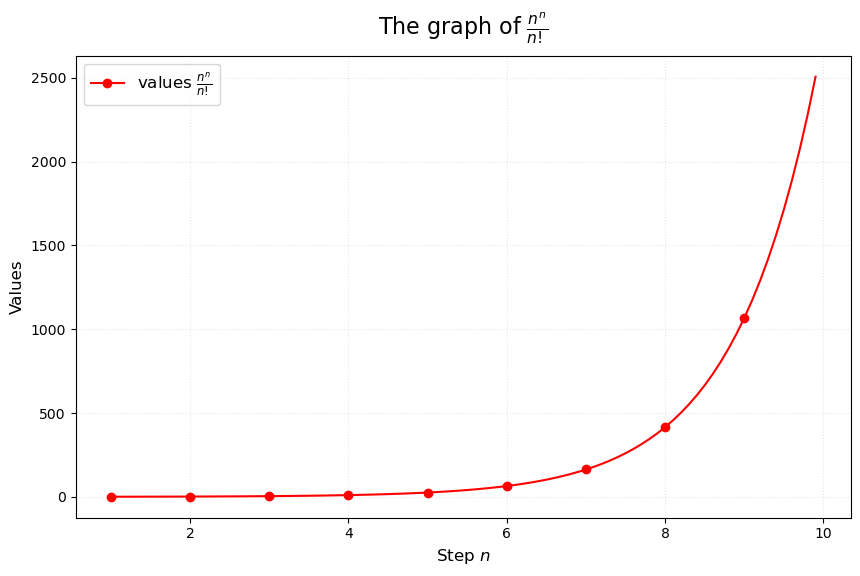

|   Step $n$ |   Numerator $n^n$ |   denominator $n!$ |   Value $\frac{n^n}{n!}$ |
|-----------:|------------------:|-------------------:|-------------------------:|
|          1 |       1           |                  1 |                   1      |
|          2 |       4           |                  2 |                   2      |
|          3 |      27           |                  6 |                   4.5    |
|          4 |     256           |                 24 |                  10.6667 |
|          5 |    3125           |                120 |                  26.0417 |
|          6 |   46656           |                720 |                  64.8    |
|          7 |  823543           |               5040 |                 163.401  |
|          8 |       1.67772e+07 |              40320 |                 416.102  |
|          9 |       3.8742e+08  |             362880 |                1067.63   |

In [7]:
# 1. Simulation setup
# We keep the range small (1 to 10) because n^n grows insanely fast.
n_max: float = 10.0
step: float = 0.1
start: float = 1.0
n_values = np.arange(start, n_max, step)
custom_mk = 10

numerators = n_values**n_values
denominators = factorial(n_values)
results = numerators / denominators

# 3. Plotting the chart
plt.figure(figsize=(10, 6))

# Draw the main line
plt.plot(n_values, results, color='red', marker='o', markevery=custom_mk, label=r'values $\frac{n^n}{n!}$')

# You may ask "why is this code excluded?"
# Let's have a look at the table of Values below
# It's reasonable not to include numerator and denominator because of the rapid growth of those values
#plt.plot(n_values, numerators, color='blue', linestyle='-', marker='s', markevery=5, label=r'numerator $n^n$')
#plt.plot(n_values, denominators, color='green', linestyle='--', marker='^', markevery=5, label=r'denominator $n!$')

# Aesthetics and labels
plt.title(r'The graph of $\frac{n^n}{n!}$', fontsize=16, pad=15)
plt.xlabel('Step $n$', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.3)
plt.legend(fontsize=12)

# Render the plot
plt.show()

table_data = {
    r"Step $n$": n_values,
    r"Numerator $n^n$": np.round(numerators, 4),
    r"denominator $n!$": np.round(denominators, 4),
    r"Value $\frac{n^n}{n!}$": np.round(results, 4)
}
df = pd.DataFrame(table_data)
df_sliced = df.iloc[::10]
Markdown(df_sliced.to_markdown(index=False))

Using our simulation, it is reasonable to say that: 
$$\LARGE \lim_{n \to \infty} \frac{n^n}{n!} = \infty$$

### 2.7
$$\LARGE\lim_{n \to \infty}\left((1+n^2)^\frac{1}{\ln n}\right)$$

**Simulation:**

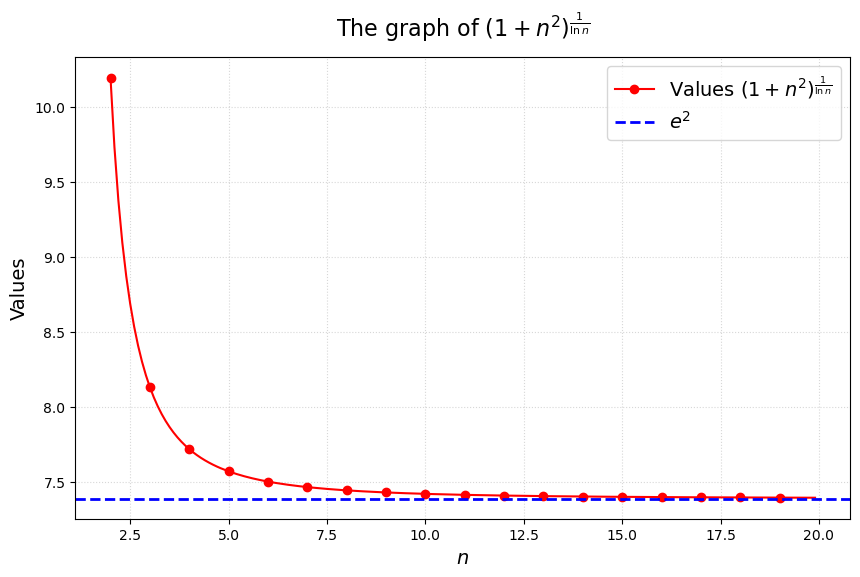

|   Step $n$ |   Base $1 + n^2$ |   Power $\frac{1}{\ln n}$ |   Values $(1+n^2)^\frac{1}{\ln n}$ |
|-----------:|-----------------:|--------------------------:|-----------------------------------:|
|          2 |      5           |                  1.4427   |                            10.1953 |
|          4 |    257           |                  0.721348 |                             7.7194 |
|          6 |  46657           |                  0.558111 |                             7.5029 |
|          8 |      1.67772e+07 |                  0.480898 |                             7.4444 |
|         10 |      1e+10       |                  0.434294 |                             7.4211 |
|         12 |      8.9161e+12  |                  0.40243  |                             7.4097 |
|         14 |      1.1112e+16  |                  0.378923 |                             7.4033 |
|         16 |      1.84467e+19 |                  0.360674 |                             7.3995 |
|         18 |      3.93464e+22 |                  0.345976 |                             7.3969 |

In [3]:
def compute():
    n_max = 20
    n_start = 2.0 
    n_step = 0.1
    n_values = np.arange(n_start, n_max, n_step)
    results = (1 + n_values**2)**(1 / np.log(n_values))
    powers = 1 / np.log(n_values)
    bases = 1 + n_values**n_values

    plt.figure(figsize=(10,6))

    plt.plot(n_values, results, color='red', linestyle="-", marker='o', markevery=10, label=r'Values $(1+n^2)^\frac{1}{\ln n}$')

    euler_value = np.exp(2)

    plt.axhline(y=euler_value, color='blue', linestyle='--',linewidth=2, label=r'$e^2$')
    plt.title(r"The graph of $(1+n^2)^\frac{1}{\ln n}$", fontsize=16, pad=15)
    plt.xlabel('$n$', fontsize=14)
    plt.ylabel('Values', fontsize=14)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend(fontsize=14, loc='upper right')

    plt.show()

    table_data = {
        r"Step $n$": n_values,
        r"Base $1 + n^2$": bases,
        r"Power $\frac{1}{\ln n}$": powers,
        r"Values $(1+n^2)^\frac{1}{\ln n}$": np.round(results, 4)
    }

    df = pd.DataFrame(table_data)
    df_sliced = df.iloc[::20]
    return Markdown(df_sliced.to_markdown(index=False))

compute()

### 2.8
$$\LARGE \lim_{n \to \infty}\frac{(n!)^2}{(2n)!}$$

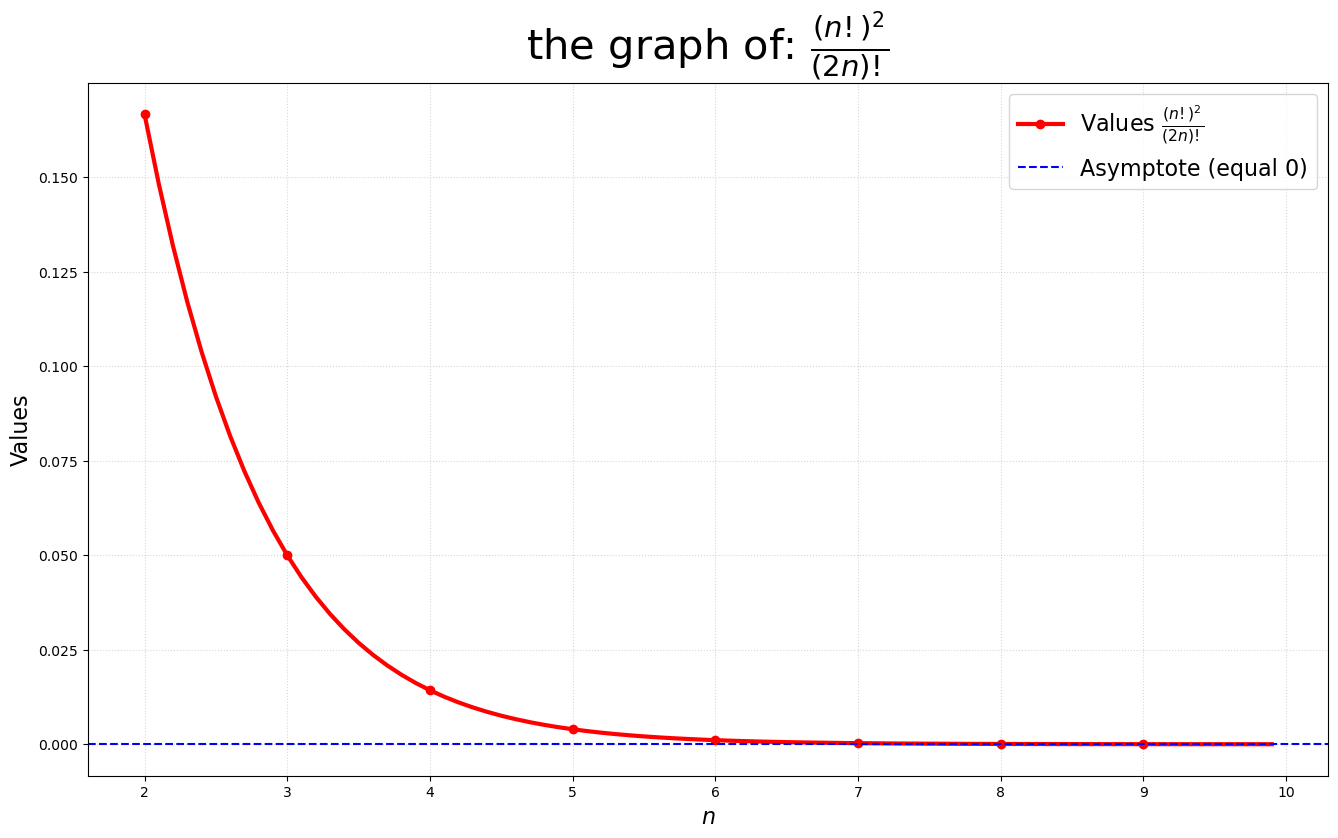

|   Step $n$ |   Numerator $(n!)^2$ |   Denominator' $(2n)!$ |   Values $\frac{(n!)^2}{(2n)!}$ |
|-----------:|---------------------:|-----------------------:|--------------------------------:|
|          2 |          4           |           24           |                          0.1667 |
|          3 |         36           |          720           |                          0.05   |
|          4 |        576           |        40320           |                          0.0143 |
|          5 |      14400           |            3.6288e+06  |                          0.004  |
|          6 |     518400           |            4.79002e+08 |                          0.0011 |
|          7 |          2.54016e+07 |            8.71783e+10 |                          0.0003 |
|          8 |          1.6257e+09  |            2.09228e+13 |                          0.0001 |
|          9 |          1.31682e+11 |            6.40237e+15 |                          0      |

In [11]:
def compute():
    n_max = 10
    n_step = 0.1
    n_start = 2
    n_values = np.arange(n_start, n_max, n_step)

    numerators = factorial(n_values)**2
    denominators = factorial(2*n_values)
    results = numerators / denominators

    plt.figure(figsize=(16,9))

    plt.plot(n_values, results, 'o-r', markevery=10, linewidth=3, label=r'Values $\frac{(n!)^2}{(2n)!}$')
    plt.axhline(y=0, linestyle='--', color='blue', label=r"Asymptote (equal 0)")
    #plt.plot(n_values, numerators, color='green', marker='^', linestyle='-', markevery=11, label=r'Numerators $(n!)^2$')

    plt.title(r'the graph of: $\frac{(n!)^2}{(2n)!}$', fontsize=30, pad=15)
    plt.xlabel(r"$n$", fontsize=16)
    plt.ylabel(r"Values", fontsize=16)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend(fontsize=16, loc='upper right')

    plt.show()

    table_data = {
        r'Step $n$': n_values,
        r'Numerator $(n!)^2$': np.round(numerators, 4),
        r"Denominator' $(2n)!$": np.round(denominators, 4),
        r"Values $\frac{(n!)^2}{(2n)!}$": np.round(results, 4)
    }

    df = pd.DataFrame(table_data)
    df_sliced = df.iloc[::10]

    return Markdown(df_sliced.to_markdown(index=False))

compute()

![2.8](./assets/2.8.png)

### 2.9
$$\LARGE \lim_{n \to \infty} n\sin \left ( \frac{1}{n} \right)$$

![2.9](./assets/2.9.png)

## Problems, Section 4
**For the following series, write formulas for the sequences $a_n$ , $S_n$ , and $R_n$ , and find the
limits of the sequences as $n \to \infty$ (if the limits exist).**

### 4.1
$$\LARGE \sum_{1}^{\infty} \frac{1}{2^n}$$

![4.1](./assets/4.1.png)

### 4.2
$$\LARGE \sum_{0}^{\infty} \frac{1}{5^n}$$

![4.2](./assets/4.2.png)

### 4.3 
$$\LARGE 1-\frac{1}{2} + \frac{1}{4} - \frac{1}{8} + \frac{1}{16} \cdots$$


![4.3](./assets/4.3.png)

### 4.4
$$\LARGE \sum_{1}^{\infty} e^{-n \ln 3}$$

![4.4](./assets/4.4.png)

### 4.5
$$
    \LARGE \sum_{0}^{\infty} e^{2n \ln \sin \left ( \frac{\pi}{3} \right ) }
$$

![4.5](./assets/4.5.png)

### 4.6 
$$
    \LARGE \sum_{1}^{\infty} \frac{1}{n(n + 1)}
$$

![4.6](./assets/4.6.png)

### 4.7
$$
    \LARGE \frac{3}{1 \cdot 2} - \frac{5}{2 \cdot 3} + \frac{7}{3 \cdot 4} - \frac{9}{4 \cdot 5} + \cdots
$$

![4.7](./assets/4.7.png)

## Problems, Section 5

**Use the preliminary test to decide whether the following series are divergent or require
further testing. Careful: Do not say that a series is convergent; the preliminary test cannot
decide this.**

### 5.1
$$\LARGE \frac{1}{2} - \frac{4}{5} + \frac{9}{10} - \frac{16}{17} + \frac{25}{26} - \frac{35}{37} + \cdots$$

![5.1](./assets/5.1.png)

### 5.2
$$\LARGE \sqrt{2} + \frac{\sqrt{3}}{2} + \frac{\sqrt{4}}{3} + \frac{\sqrt{5}}{4} + \frac{\sqrt{6}}{5}+ \cdots$$

![5.2](./assets/5.2.png)

### 5.3
$$\LARGE \sum_{n=1}^{\infty} \frac{n+3}{n^2 + 10n}$$

![5.3](./assets/5.3.png)

### 5.4
$$
\LARGE \sum_{(-1)^n n^2}^{(n+1)!}
$$

![5.4](./assets/5.4.png)

### 5.5
$$
    \LARGE \sum^{\infty}_{n=1} \frac{n!}{n! + 1}
$$

![5.5](./assets/5.5.png)

### 5.6
$$
    \LARGE \sum^{\infty}_{n=1} \frac{n!}{(n + 1)!}
$$

![5.6](./assets/5.6.png)

### 5.7
$$
\LARGE \sum^{\infty}_{n=1}\frac{(-1)^n n}{\sqrt{n^3 + 1}}
$$

![5.7](./assets/5.7.png)

### 5.8 
$$
\LARGE \sum^{\infty}_{n=1} \frac{\ln{n}}{n}
$$

![5.8](./assets/5.8.png)

### 5.9
$$
\LARGE \sum^{\infty}_{n=1} \frac{3^n}{2^n + 3^n}
$$

![5.9](./assets/5.9.png)

### 5.10
$$
\LARGE \sum^{\infty}_{n=2} \left ( 1 - \frac{1}{n^2} \right )
$$

![5.10](./assets/5.10.png)

### 5.11
**Give a proof of the preliminary test.**
<br>
*Hint: $S_n - S_{n-1} = a_n$*

![5.11](./assets/5.11.png)

## Problems, Section 6

### A. The Comparison Test 

#### 6.1
**Show that $n! > 2^n$ for all $n > 3$.**
<br>
*Hint: Write out a few terms; then consider what you multiply by to go from, say $5!$ to $6!$ and from $2^5$ to $2^6$*

![6.1](./assets/6.1.png)

#### 6.2 
**Prove that the harmonic series $\sum^{\infty}_{n=1} \frac{1}{n} is divergent$**

![6.2](./assets/6.2.png)

#### 6.3
**Prove the convergence of $\sum^{\infty}_{n = 1} \frac{1}{n^2}$ by grouping terms somewhat as in Problem 6.2**

![6.3](./assets/6.3.png)

#### 6.4
**Use the comparison test to prove the convergence of the follwoing series**

##### 6.4 a)
$$
\LARGE \sum^{\infty}_{n=1} \frac{1}{2^n + 3^n}
$$

![6.4.a](./assets/6.4.a.png)

##### 6.4 b)
$$
\LARGE \sum^{\infty}_{n=1} \frac{1}{n2^n}
$$

![6.4.b](./assets/6.4.b.png)

#### 6.5 
**Test the following series for convergence using the comparison test.**

##### 6.5 a)
$$
\LARGE \sum^{\infty}_{n=1} \frac{1}{\sqrt{n}}
$$

![6.5.a](./assets/6.5.a.png)

##### 6.5 b)
**Test the following series for convergence using the comparison test.**
$$\LARGE \sum_{n=2}^{\infty} \frac{1}{\ln n}$$

###### Proof of Divergence for $H = \sum \frac{1}{\ln n}$

To determine the convergence of the series $\sum_{n=2}^{\infty} \frac{1}{\ln n}$, we will use the Direct Comparison Test. 

We choose the harmonic series as our reference divergent series:
$$D = \sum_{n=2}^{\infty} \frac{1}{n}$$
*(We know from previous proofs that the harmonic series is divergent).*

Now, we compare the terms of both series. For all $n \ge 2$, it is a known property of the natural logarithm that it grows slower than linear function:
$$\ln n < n$$

Since the denominator of our $H$ series is strictly smaller than the denominator of the $D$ series, taking the reciprocal reverses the inequality:
$$\frac{1}{\ln n} > \frac{1}{n}$$

Since our series $H$ is strictly greater term-by-term than the divergent harmonic series $D$, it follows by the Direct Comparison Test that $H$ must also be divergent:
$$\sum_{n=2}^{\infty} \frac{1}{\ln n} = \infty$$

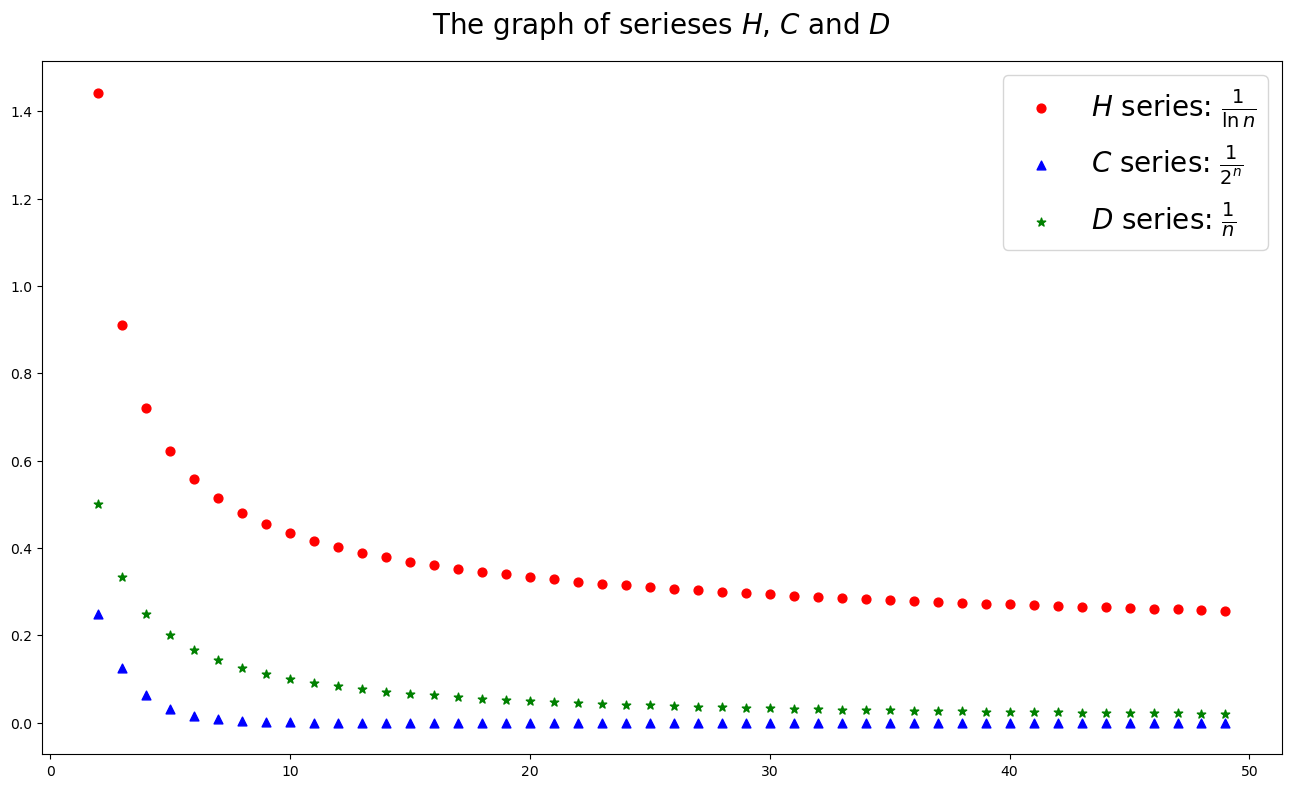

|   Step $n$ |   Series $H$ values |   Series $C$ values |   Series $D$ values |
|-----------:|--------------------:|--------------------:|--------------------:|
|          2 |              1.4427 |              0.25   |              0.5    |
|          7 |              0.5139 |              0.0078 |              0.1429 |
|         12 |              0.4024 |              0.0002 |              0.0833 |
|         17 |              0.353  |              0      |              0.0588 |
|         22 |              0.3235 |              0      |              0.0455 |
|         27 |              0.3034 |              0      |              0.037  |
|         32 |              0.2885 |              0      |              0.0312 |
|         37 |              0.2769 |              0      |              0.027  |
|         42 |              0.2675 |              0      |              0.0238 |
|         47 |              0.2597 |              0      |              0.0213 |

In [5]:
def plot_graph():
    n_max = 50
    n_start = 2
    n_step = 1
    n_values = np.arange(n_start, n_max, n_step)
    h_values = 1/ np.log(n_values)
    c_values = 1/ 2 ** n_values
    d_values = 1/ n_values

    plt.figure(figsize=(16,9))

    plt.scatter(n_values, h_values, color='red', marker='o', s=40, label=r'$H$ series: $\frac{1}{\ln n}$')
    plt.scatter(n_values, c_values, color='blue', s=40, marker='^', label=r'$C$ series: $\frac{1}{2^n}$')
    plt.scatter(n_values, d_values, color='green', s=40, marker='*', label=r'$D$ series: $\frac{1}{n}$')

    plt.legend(loc='upper right', fontsize=20)
    plt.title(r"The graph of serieses $H$, $C$ and $D$", fontsize=20, pad= 20)

    plt.show()

    table_data = {
        r"Step $n$": n_values,
        r"Series $H$ values": np.round(h_values, 4) ,
        r"Series $C$ values": np.round(c_values, 4),
        r"Series $D$ values": np.round(d_values,4)
    }

    df = pd.DataFrame(table_data)
    df_sliced = df.iloc[::5]
    return Markdown(df_sliced.to_markdown(index=False))

plot_graph()

![6.5.b](./assets/6.5.b.png)

#### 6.6 
**There are 9 one-digit numbers (1 to 9), 90 two-digit numbers (10 to 99). How many
three-digit, four-digit, etc., numbers are there? The first 9 terms of the harmonic
series $1 + \frac{1}{2} + \frac{1}{3} + \cdots + \frac{1}{9}$ are all greater than $\frac{1}{10}$; similarly consider the next 90
terms, and so on. Thus prove the divergence of the harmonic series by comparison
with the series**

$$
\LARGE D = \left [\frac{1}{10} + \cdots (\text{9 terms each} = \frac{1}{10} \right ] + \left [ \text{90 terms each} = \frac{1}{100} \right] + \cdots
$$

![6.6](./assets/6.6.png)

### B. The Integral Test

#### Use the integral test to find whether the following series converge or diverge. Hint and
*warning: Do not use lower limits on your integrals* 


##### 6.7
$$
\LARGE \sum^{\infty}_{n=2} \frac{1}{n \ln{n}}
$$

![6.7](./assets/6.7.png)

##### 6.8
$$
\LARGE \sum^{\infty}_{n=1} \frac{n}{n^2 + 4}
$$

![6.8](./assets/6.8.png)

##### 6.9
$$
\LARGE \sum^{\infty}_{n=3} \frac{1}{n^2 - 4}
$$

![6.9](./assets/6.9.png)

##### 6.10 
$$
\LARGE \sum^{\infty}_{n=1} \frac{e^n}{e^{2n} + 9}
$$

![6.10](./assets/6.10.png)